In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Re-fetch and scale data (Same as Task 2)
tsla = yf.download('TSLA', start='2015-01-01', end='2025-01-01', auto_adjust=True)['Close']
tsla = tsla.dropna()

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(tsla.values.reshape(-1, 1))

# 2. Re-create the model structure (so we can use the weights)
# In a real project, you would load a saved .h5 file, but we will quickly re-fit
# to keep it simple for now. 
X, y = [], []
for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])
X, y = np.array(X), np.array(y)
X = X.reshape(X.shape[0], X.shape[1], 1)

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=5, batch_size=32, verbose=0)

[*********************100%***********************]  1 of 1 completed
c:\Users\DELL 7020\Desktop\portfolio-optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [2]:
# 3. Start with the last 60 days of known data
current_batch = scaled_data[-60:].reshape(1, 60, 1)
future_predictions = []

# 4. Predict 180 days into the future
for i in range(180):
    # Get the prediction for the next day
    current_pred = model.predict(current_batch, verbose=0)
    
    # Store the prediction
    future_predictions.append(current_pred[0])
    
    # Update the batch: Remove the first day, append the new prediction
    current_batch = np.append(current_batch[:, 1:, :], [current_pred], axis=1)

# 5. Inverse transform to get actual dollar prices
future_predictions = scaler.inverse_transform(future_predictions)

# 6. Create dates for the future
last_date = tsla.index[-1]
future_dates = pd.date_range(start=last_date, periods=181, freq='B')[1:] # 'B' for business days

forecast_df = pd.Series(future_predictions.flatten(), index=future_dates)

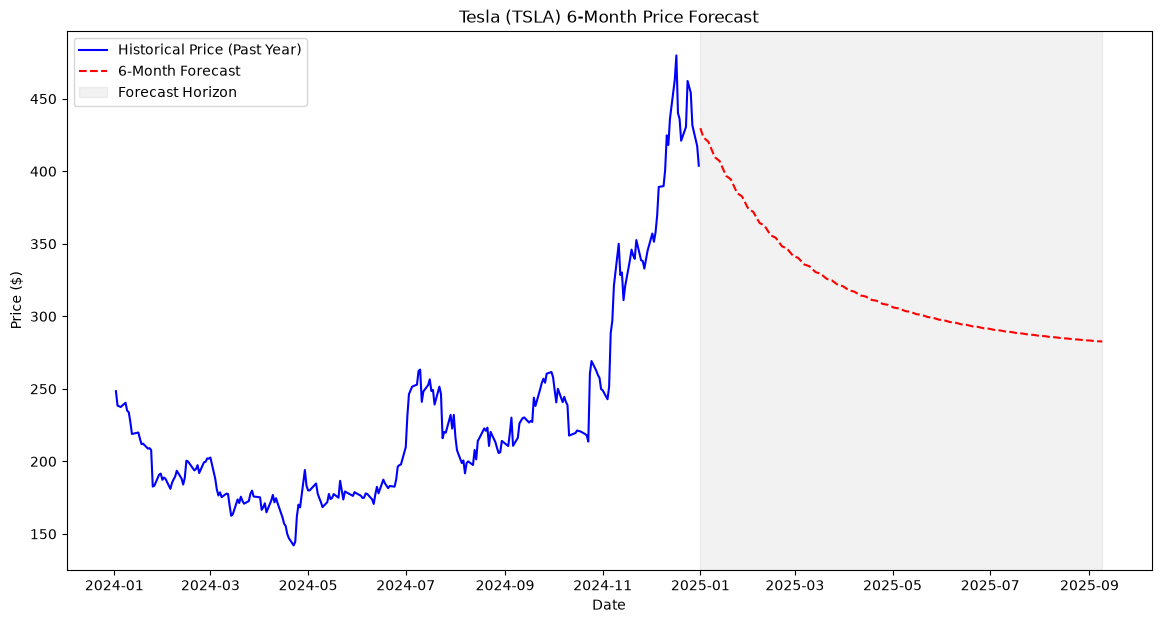

In [3]:
plt.figure(figsize=(14,7))

# Plot last 1 year of historical data
plt.plot(tsla.tail(252), label='Historical Price (Past Year)', color='blue')

# Plot Future Forecast
plt.plot(forecast_df, label='6-Month Forecast', color='red', linestyle='--')

# Highlight the Forecast Area
plt.axvspan(future_dates[0], future_dates[-1], color='gray', alpha=0.1, label='Forecast Horizon')

plt.title('Tesla (TSLA) 6-Month Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()